# 6 Modellbildung, Datenanalyse und Algorithmen

## 6.2 Analyse der Datenstruktur und Zusammenhänge

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("tmdb_5000_cleaned neu.csv", sep=";")

In [6]:
df.head()

,title,budget,runtime,release_year,is_us_production,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,...,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_War,genre_Western,popularity
0,Avatar,237000000,162.0,2009.0,1,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,150.437577
1,Pirates of the Caribbean: At World's End,300000000,169.0,2007.0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,139.082615
2,Spectre,245000000,148.0,2015.0,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,107.376788
3,The Dark Knight Rises,250000000,165.0,2012.0,1,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,112.312950
4,John Carter,260000000,132.0,2012.0,1,1,1,0,0,0,...,0,0,0,0,1,0,0,0,0,43.926995


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3764 entries, 0 to 3763
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  3764 non-null   object 
 1   budget                 3764 non-null   int64  
 2   runtime                3764 non-null   float64
 3   release_year           3764 non-null   float64
 4   is_us_production       3764 non-null   int64  
 5   genre_Action           3764 non-null   int64  
 6   genre_Adventure        3764 non-null   int64  
 7   genre_Animation        3764 non-null   int64  
 8   genre_Comedy           3764 non-null   int64  
 9   genre_Crime            3764 non-null   int64  
 10  genre_Documentary      3764 non-null   int64  
 11  genre_Drama            3764 non-null   int64  
 12  genre_Family           3764 non-null   int64  
 13  genre_Fantasy          3764 non-null   int64  
 14  genre_Foreign          3764 non-null   int64  
 15  genr

In [8]:

pd.options.display.float_format = '{:,.2f}'.format

In [9]:
df.describe()

,budget,runtime,release_year,is_us_production,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,...,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_War,genre_Western,popularity
count,"3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00",...,"3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00","3,764.00"
mean,"37,058,535.21",109.32,"2,002.08",0.88,0.27,0.19,0.06,0.35,0.16,0.01,...,0.11,0.04,0.08,0.18,0.13,0.00,0.29,0.04,0.02,26.00
std,"42,652,055.19",20.75,12.88,0.33,0.44,0.39,0.23,0.48,0.36,0.12,...,0.31,0.19,0.27,0.38,0.33,0.03,0.45,0.18,0.13,34.44
min,1.00,0.00,"1,916.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"8,000,000.00",95.00,"1,998.75",1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.98
50%,"23,000,000.00",105.50,"2,005.00",1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.61
75%,"50,000,000.00",120.00,"2,011.00",1.00,1.00,0.00,0.00,1.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,33.93
max,"380,000,000.00",338.00,"2,016.00",1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,875.58


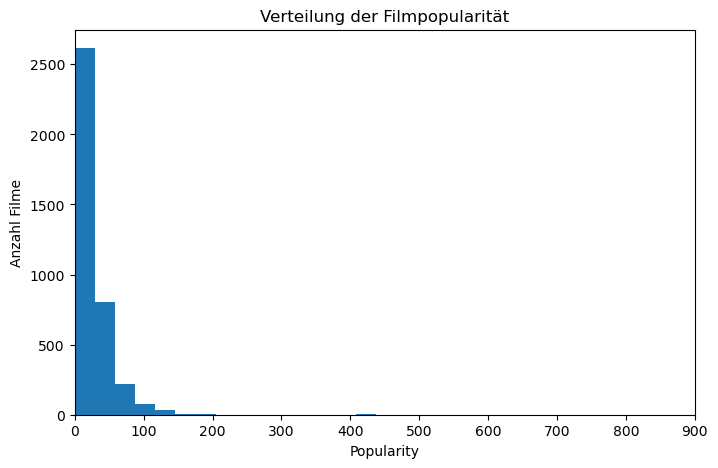

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['popularity'], bins=30)

plt.xlim(0, 900)

plt.xlabel("Popularity")
plt.ylabel("Anzahl Filme")
plt.title("Verteilung der Filmpopularität")

plt.show()

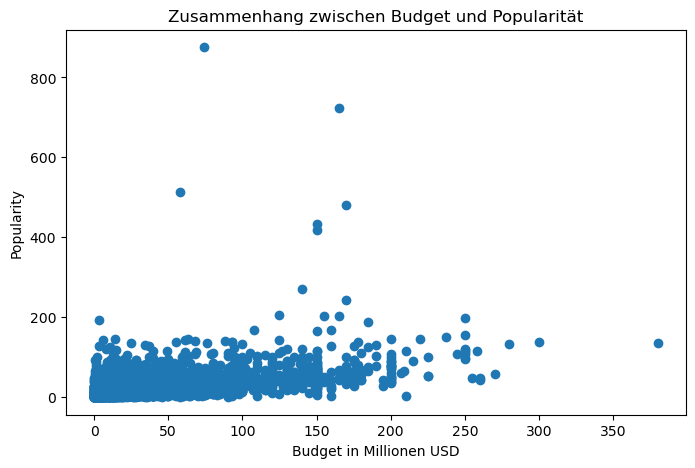

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(df['budget'] / 1000000, df['popularity'])

plt.xlabel("Budget in Millionen USD")
plt.ylabel("Popularity")
plt.title("Zusammenhang zwischen Budget und Popularität")

plt.show()

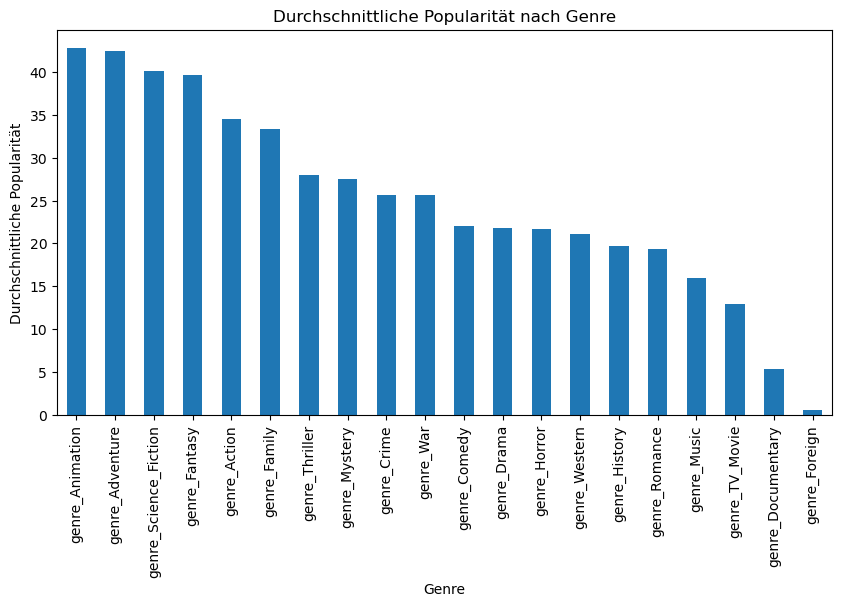

In [12]:
genre_columns = [col for col in df.columns if "genre_" in col]

genre_popularity = {}

for genre in genre_columns:
    genre_popularity[genre] = df[df[genre] == 1]['popularity'].mean()

genre_popularity = pd.Series(genre_popularity).sort_values(ascending=False)

plt.figure(figsize=(10,5))

genre_popularity.plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Durchschnittliche Popularität")
plt.title("Durchschnittliche Popularität nach Genre")

plt.show()

## 6.3 Modelltraining

### 6.3.1 Train-Test-Split

In [13]:
# Eingabemerkmale und Zielvariable definieren
X = df.drop(columns=['title', 'popularity'])

y = df['popularity']

In [14]:
# Train-Test-Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=365
)

In [15]:
# Größe der Trainings- und Testdaten prüfen
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3011, 24)
(753, 24)
(3011,)
(753,)


### Skalierung der Daten

In [16]:
# Skalierung der Daten
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6.3.2 Multiple Lineare Regression

In [17]:
# Multiple Lineare Regression
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()

model_lr.fit(X_train_scaled, y_train)

LinearRegression()

### 6.3.3 Random Forest Regressor

In [18]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=365
)

model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=365)

## 7 Deployment-Prototyp

In [19]:
# Beispielhafter neuer Film für eine Popularitätsprognose

new_movie = pd.DataFrame(0, index=[0], columns=X.columns)

new_movie.loc[0, 'budget'] = 80000000
new_movie.loc[0, 'runtime'] = 120
new_movie.loc[0, 'release_year'] = 2026
new_movie.loc[0, 'is_us_production'] = 1

new_movie.loc[0, 'genre_Action'] = 1
new_movie.loc[0, 'genre_Adventure'] = 1
new_movie.loc[0, 'genre_Science_Fiction'] = 1

new_movie

,budget,runtime,release_year,is_us_production,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_War,genre_Western
0,80000000,120,2026,1,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [20]:
# Vorhersage mit dem Random Forest Regressor

predicted_popularity_rf = model_rf.predict(new_movie)

print("Vorhergesagte Popularität (Random Forest):", round(predicted_popularity_rf[0], 2))

Vorhergesagte Popularität (Random Forest): 80.98


In [21]:
# Vorhersage mit der Multiplen Linearen Regression

new_movie_scaled = scaler.transform(new_movie)

predicted_popularity_lr = model_lr.predict(new_movie_scaled)

print("Vorhergesagte Popularität (Lineare Regression):", round(predicted_popularity_lr[0], 2))

Vorhergesagte Popularität (Lineare Regression): 53.97


## 8 Evaluation

### 8.1 Berechnung der Evaluationsmetriken

In [22]:
# Evaluationsmetriken importieren
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [23]:
# Vorhersagen auf den Testdaten

y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_rf = model_rf.predict(X_test)

In [24]:
# Funktion für Adjusted R²

def adjusted_r2_score(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [25]:
# Evaluation Multiple Lineare Regression

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
adj_r2_lr = adjusted_r2_score(r2_lr, X_test.shape[0], X_test.shape[1])

print("Multiple Lineare Regression")
print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²:", round(r2_lr, 2))
print("Adjusted R²:", round(adj_r2_lr, 2))

Multiple Lineare Regression
MAE: 16.31
RMSE: 36.88
R²: 0.21
Adjusted R²: 0.19


In [26]:
# Evaluation Random Forest Regressor

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
adj_r2_rf = adjusted_r2_score(r2_rf, X_test.shape[0], X_test.shape[1])

print("Random Forest Regressor")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²:", round(r2_rf, 2))
print("Adjusted R²:", round(adj_r2_rf, 2))

Random Forest Regressor
MAE: 16.5
RMSE: 36.16
R²: 0.24
Adjusted R²: 0.22


In [27]:
# Vergleich der Modelle

evaluation_results = pd.DataFrame({
    'Modell': ['Multiple Lineare Regression', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf],
    'Adjusted R²': [adj_r2_lr, adj_r2_rf]
})

evaluation_results.round(2)

,Modell,MAE,RMSE,R²,Adjusted R²
0,Multiple Lineare Regression,16.31,36.88,0.21,0.19
1,Random Forest Regressor,16.50,36.16,0.24,0.22


## Overfitting-Test anhand der Trainingsdaten

In [32]:
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_rf = model_rf.predict(X_test)

In [33]:
# Vorhersagen auf den Trainingsdaten

y_train_pred_lr = model_lr.predict(X_train_scaled)
y_train_pred_rf = model_rf.predict(X_train)

In [34]:
# Evaluation auf den Trainingsdaten

mae_lr_train = mean_absolute_error(y_train, y_train_pred_lr)
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
r2_lr_train = r2_score(y_train, y_train_pred_lr)
adj_r2_lr_train = adjusted_r2_score(r2_lr_train, X_train.shape[0], X_train.shape[1])

mae_rf_train = mean_absolute_error(y_train, y_train_pred_rf)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
r2_rf_train = r2_score(y_train, y_train_pred_rf)
adj_r2_rf_train = adjusted_r2_score(r2_rf_train, X_train.shape[0], X_train.shape[1])

In [36]:
overfitting_check = pd.DataFrame({
    'Modell': [
        'Multiple Lineare Regression - Training',
        'Multiple Lineare Regression - Test',
        'Random Forest Regressor - Training',
        'Random Forest Regressor - Test'
    ],
    'MAE': [
        mae_lr_train,
        mae_lr,
        mae_rf_train,
        mae_rf
    ],
    'RMSE': [
        rmse_lr_train,
        rmse_lr,
        rmse_rf_train,
        rmse_rf
    ],
    'R²': [
        r2_lr_train,
        r2_lr,
        r2_rf_train,
        r2_rf
    ],
    'Adjusted R²': [
        adj_r2_lr_train,
        adj_r2_lr,
        adj_r2_rf_train,
        adj_r2_rf
    ]
})

overfitting_check.round(2)

,Modell,MAE,RMSE,R²,Adjusted R²
0,Multiple Lineare Regression - Training,14.78,27.96,0.26,0.25
1,Multiple Lineare Regression - Test,16.31,36.88,0.21,0.19
2,Random Forest Regressor - Training,5.49,10.77,0.89,0.89
3,Random Forest Regressor - Test,16.50,36.16,0.24,0.22


### 8.2 Feature Importance des Random Forest

In [28]:
# Feature Importance des Random Forest

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,budget,0.42
1,runtime,0.20
2,release_year,0.17
21,genre_Thriller,0.04
19,genre_Science_Fiction,0.03
5,genre_Adventure,0.02
7,genre_Comedy,0.02
8,genre_Crime,0.01
12,genre_Fantasy,0.01
10,genre_Drama,0.01


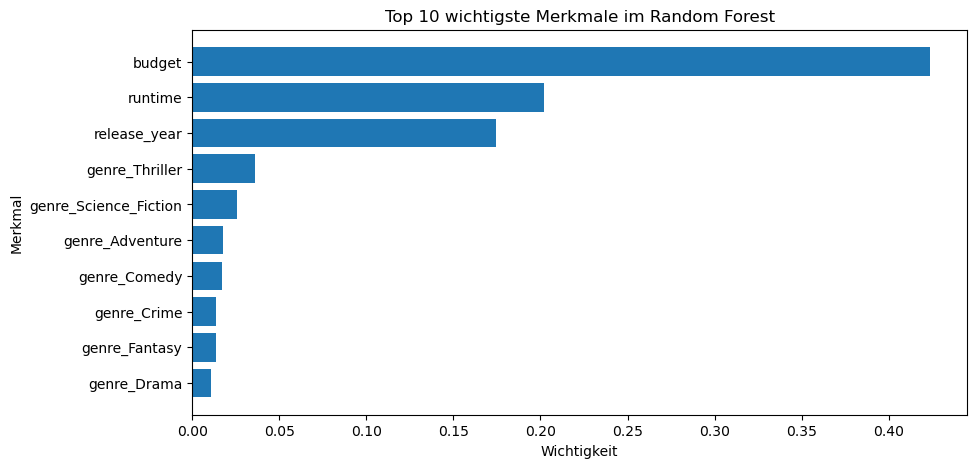

In [29]:
# Top 10 wichtigste Merkmale visualisieren

top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Wichtigkeit")
plt.ylabel("Merkmal")
plt.title("Top 10 wichtigste Merkmale im Random Forest")

plt.gca().invert_yaxis()
plt.show()

## Anhang: Eigene Analysen (kein Teil der Hausarbeit)

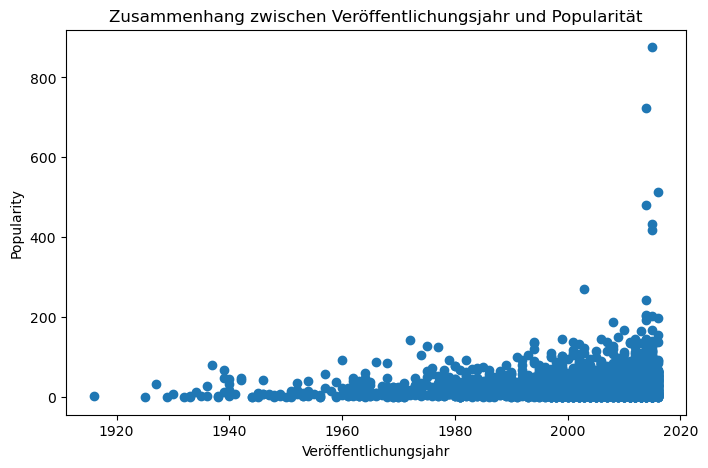

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(df['release_year'], df['popularity'])

plt.xlabel("Veröffentlichungsjahr")
plt.ylabel("Popularity")
plt.title("Zusammenhang zwischen Veröffentlichungsjahr und Popularität")

plt.show()